# Optimal Experimental Design: Choosing the Rotation Angles of a DRRP Polarimeter
_written by Jaren N. Ashcraft_

In the [companion tutorial](BayesianPolarimetry.ipynb) we *calibrated* a dual-rotating-retarder (DRRP) polarimeter: given a fixed set of retarder rotation angles, we recovered the six instrument parameters and their posterior covariance. That notebook took the **measurement schedule** — the list of commanded rotation angles $\{\theta_i\}$ — as a given, a uniform sweep $\theta \in [0,\pi]$.

But the schedule is a *design choice*, and it is one of the few things an experimenter fully controls. Different schedules spread the sample's Mueller elements across the modulation harmonics differently, and therefore produce **different posterior covariances**. This notebook asks the optimal-experimental-design question:

> Which rotation angles should we command so that the calibration is as precise as possible?

The key object is the **Fisher information matrix** $\mathbf{F}$. Under the Laplace approximation it is the Hessian of the negative log-posterior at the solution, and its inverse is the parameter covariance $\mathbf{C}=\mathbf{F}^{-1}$. Crucially, $\mathbf{F}$ depends on the schedule through the Jacobian of the model outputs with respect to the parameters:

$$\mathbf{F}(\{\theta_i\}) \;=\; \frac{1}{\sigma^2}\,\mathbf{J}^\top \mathbf{J} \;+\; \mathbf{F}_{\text{prior}},\qquad J_{ik}=\frac{\partial\, m(\theta_i)}{\partial\, p_k}.$$

Because `katsu` is built on `jax`, $\mathbf{F}$ is a **differentiable function of the schedule**. We can therefore descend a scalar summary of the covariance directly, using the same `optax` machinery the calibration used — only now the *rotation angles* are the free variables and the six instrument parameters are held at their nominal values. Two classic design criteria:

| criterion | scalar objective | geometric meaning | matches |
| --- | --- | --- | --- |
| **A-optimality** | $\operatorname{tr}\mathbf{C}$ | sum of marginal variances | "tighter marginal bounds" |
| **D-optimality** | $-\log\det\mathbf{F}$ | volume of the joint confidence ellipsoid | "minimum measurement covariance" |

A caveat worth stating up front: $\mathbf{F}$ depends on the (unknown) true parameters, so we optimize at our best *nominal* guess of the instrument. This is **locally optimal design** — perfectly standard, and in practice one iterates design ↔ calibration.

In [1]:
import os

from katsu.katsu_math import np, set_backend_to_jax
set_backend_to_jax()  # must happen before we build any models

import jax
import optax
import blackjax
import pandas as pd
import matplotlib.pyplot as plt

from katsu.models import Model, LinearDiattenuator, MuellerMatrix
from katsu.mueller import linear_retarder

## The rotating-retarder element

This is the same small custom element from the calibration notebook. A DRRP retarder's fast axis at each measurement state is `start_angle + rotation`, where `rotation` is the *commanded* angle read off the stage encoders and `start_angle` is the scalar mounting offset. Only the scalar physical parameters are differentiable leaves; the `rotation` array rides along as data.

The difference in *this* notebook is what we differentiate with respect to: we will take gradients through the `rotation` array itself.

In [2]:
class RotatingRetarder(MuellerMatrix):
    '''Linear retarder whose fast axis is ``start_angle + rotation``.

    ``rotation`` is the known commanded fast-axis angle at every measurement
    state; ``start_angle`` is the unknown scalar mounting offset.
    '''

    start_angle: float
    retardance: float
    rotation: np.ndarray
    shape: tuple

    def __init__(self, start_angle, retardance, rotation):
        self.start_angle = start_angle
        self.retardance = retardance
        self.rotation = rotation
        self.shape = rotation.shape

    @property
    def matrix(self):
        return linear_retarder(
            self.start_angle + self.rotation, self.retardance, shape=self.shape
        )

## The instrument as a pure function of (parameters, schedule)

To differentiate the Fisher matrix with respect to the schedule, we express the detected power as a plain function of two arguments: the vector of six physical parameters `pvec` and the retarder-1 rotation schedule `sched`. Retarder 2 is geared to rotate `GEAR = 5` times faster. The observed intensity is the top-left element of the system Mueller matrix acting on the unpolarized input.

We fix the six parameters at a **nominal** instrument — polarizers a couple of degrees off horizontal, retardances a few degrees from quarter-wave, small mounting offsets — exactly the "truth" the calibration notebook recovered. The design is optimized at this nominal point.

In [3]:
N = 64                       # number of measurement states
GEAR = 5                     # retarder-2 rotates 5x faster than retarder-1
sigma = 0.01                 # per-measurement read noise
stokes = np.array([1.0, 0.0, 0.0, 0.0])  # unpolarized input

# The six calibration parameters, in a fixed order (jax flattens in this order).
order = [
    "pol_gen.transmission_axis",
    "ret1.retardance", "ret1.start_angle",
    "ret2.retardance", "ret2.start_angle",
    "pol_ana.transmission_axis",
]

# Nominal instrument to design around (radians).
nominal = np.array([
    np.radians(2.0),    # generator polarizer axis
    np.radians(95.0),   # retarder-1 retardance
    np.radians(3.0),    # retarder-1 start angle
    np.radians(88.0),   # retarder-2 retardance
    np.radians(-4.0),   # retarder-2 start angle
    np.radians(-3.0),   # analyzer polarizer axis
])

# Weakly-informative priors centred on the *design* instrument (as in calibration).
prior_mu = {
    "pol_gen.transmission_axis": 0.0,
    "pol_ana.transmission_axis": 0.0,
    "ret1.retardance": np.pi / 2,
    "ret2.retardance": np.pi / 2,
    "ret1.start_angle": 0.0,
    "ret2.start_angle": 0.0,
}
prior_sigma = 0.2                                # ~11 deg
prior_precision = np.eye(6) / prior_sigma ** 2   # F_prior


def build_system(pvec, sched):
    '''Assemble the DRRP for a parameter vector and a rotation schedule.'''
    p = {k: pvec[i] for i, k in enumerate(order)}
    return Model([
        ("pol_gen", LinearDiattenuator(p["pol_gen.transmission_axis"], 0.0)),
        ("ret1", RotatingRetarder(p["ret1.start_angle"], p["ret1.retardance"], sched)),
        ("ret2", RotatingRetarder(p["ret2.start_angle"], p["ret2.retardance"], GEAR * sched)),
        ("pol_ana", LinearDiattenuator(p["pol_ana.transmission_axis"], 0.0)),
    ])


def predict(pvec, sched):
    '''Detected power at every measurement state.'''
    return build_system(pvec, sched).forward(stokes)[..., 0]

## The Fisher information matrix as a function of the schedule

We build $\mathbf{F}$ from the Jacobian of `predict` with respect to the six parameters, evaluated at the nominal instrument. `jax.jacrev` gives us the $N\times 6$ Jacobian; the Fisher matrix is $\mathbf{J}^\top\mathbf{J}/\sigma^2$ plus the prior precision. The predicted parameter covariance is $\mathbf{C}=\mathbf{F}^{-1}$, and the **marginal 1-$\sigma$ bounds** are $\sqrt{\operatorname{diag}\mathbf{C}}$.

Every step here is differentiable in `sched`, so the whole covariance is too.

In [4]:
def fisher(sched, pvec=nominal):
    J = jax.jacrev(lambda v: predict(v, sched))(pvec)   # (N, 6)
    return (J.T @ J) / sigma ** 2 + prior_precision      # (6, 6)


def marginal_sigmas_deg(sched):
    C = np.linalg.inv(fisher(sched))
    return np.degrees(np.sqrt(np.diag(C)))


# Baseline schedule: the uniform sweep used in the calibration notebook.
baseline = np.linspace(0, np.pi, N)

print("baseline marginal 1-sigma [deg]:")
for k, s in zip(order, marginal_sigmas_deg(baseline)):
    print(f"  {k:28s} {float(s):7.3f}")

baseline marginal 1-sigma [deg]:
  pol_gen.transmission_axis      5.741
  ret1.retardance                0.742
  ret1.start_angle               5.735
  ret2.retardance                0.757
  ret2.start_angle               5.736
  pol_ana.transmission_axis      5.740


## Two design criteria

We now define the two scalar objectives. **A-optimality** literally minimizes the sum of the marginal variances — the most direct reading of "tighter marginal bounds." **D-optimality** maximizes $\log\det\mathbf{F}$, which minimizes the volume of the joint confidence ellipsoid $\propto (\det\mathbf{F})^{-1/2}$ — a global "minimum covariance" criterion that, unlike the trace, is not dominated by whichever single parameter happens to have the largest variance.

In [5]:
def a_optimality(sched):
    '''Sum of marginal variances = trace of the covariance.'''
    return np.trace(np.linalg.inv(fisher(sched)))


def neg_logdet_fisher(sched):
    '''D-optimality objective: minimize -log det F  <=>  shrink the joint ellipsoid.'''
    return -np.linalg.slogdet(fisher(sched))[1]

## Optimizing the schedule for tighter marginals (A-optimality)

We descend `a_optimality` with Adam, starting from the uniform baseline schedule and letting all `N` rotation angles move freely (a retarder's fast axis is periodic mod $\pi$, so unbounded angles are fine). This is the identical optimization pattern the calibration used — only the free variable has changed from *instrument parameters* to *rotation angles*.

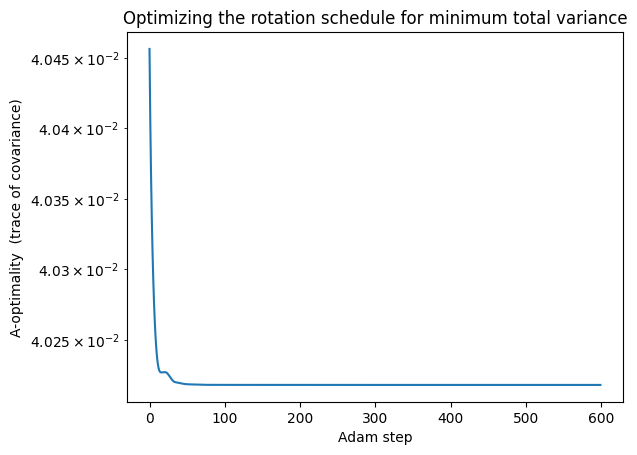

In [6]:
sched = baseline
optimizer = optax.adam(1e-2)
opt_state = optimizer.init(sched)

value_and_grad = jax.jit(jax.value_and_grad(a_optimality))

a_losses = []
for step in range(600):
    loss, grads = value_and_grad(sched)
    updates, opt_state = optimizer.update(grads, opt_state)
    sched = optax.apply_updates(sched, updates)
    a_losses.append(float(loss))

sched_A = sched

plt.figure()
plt.plot(a_losses)
plt.xlabel("Adam step")
plt.ylabel("A-optimality  (trace of covariance)")
plt.title("Optimizing the rotation schedule for minimum total variance")
plt.yscale("log")
plt.show()

### What moved, and what didn't

Comparing the baseline and A-optimal schedules parameter by parameter is revealing. The **retardances** $\delta_1,\delta_2$ — the parameters the modulation curve constrains most strongly — tighten substantially. The polarizer axes and retarder start angles barely budge: they sit in the near-degenerate $p_i\!-\!\theta_i$ subspace exposed by the corner plot in the calibration notebook (rotating a polarizer looks almost like rotating its neighbouring retarder), so they are essentially **prior-limited** and no rotation schedule can rescue them.

This is exactly why the *total* trace moves so little while the retardance bounds shrink a lot: A-optimality on raw variances is dominated by the large, near-degenerate directions, which have little leverage left to give. The achievable win lives entirely in the well-conditioned retardance directions.

parameter                      baseline  A-optimal    change
  pol_gen.transmission_axis      5.741      5.736     -0.1%
  ret1.retardance                0.742      0.468    -36.9%
  ret1.start_angle               5.735      5.733     -0.0%
  ret2.retardance                0.757      0.520    -31.3%
  ret2.start_angle               5.736      5.734     -0.0%
  pol_ana.transmission_axis      5.740      5.735     -0.1%


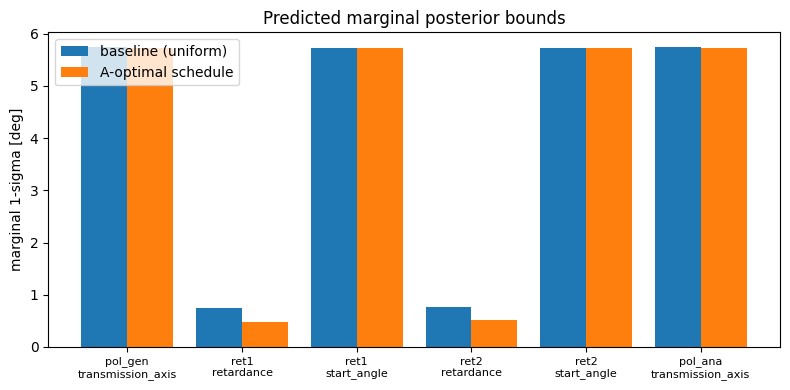

In [7]:
sig0 = marginal_sigmas_deg(baseline)
sigA = marginal_sigmas_deg(sched_A)

print(f"{'parameter':28s} {'baseline':>10s} {'A-optimal':>10s} {'change':>9s}")
for k, a, b in zip(order, sig0, sigA):
    print(f"  {k:26s} {float(a):9.3f} {float(b):10.3f} {100*(float(b)/float(a)-1):+8.1f}%")

x = np.arange(len(order))
plt.figure(figsize=(8, 4))
plt.bar(x - 0.2, jax.device_get(sig0), width=0.4, label="baseline (uniform)")
plt.bar(x + 0.2, jax.device_get(sigA), width=0.4, label="A-optimal schedule")
plt.xticks(x, [k.replace(".", "\n") for k in order], fontsize=8)
plt.ylabel("marginal 1-sigma [deg]")
plt.title("Predicted marginal posterior bounds")
plt.legend()
plt.tight_layout()
plt.show()

### Where does the optimal schedule place its measurements?

Plotting the commanded retarder-1 angles, sorted, shows how the optimizer redistributes the sampling away from the perfectly uniform sweep — clustering measurement states where the retardance harmonics carry the most information.

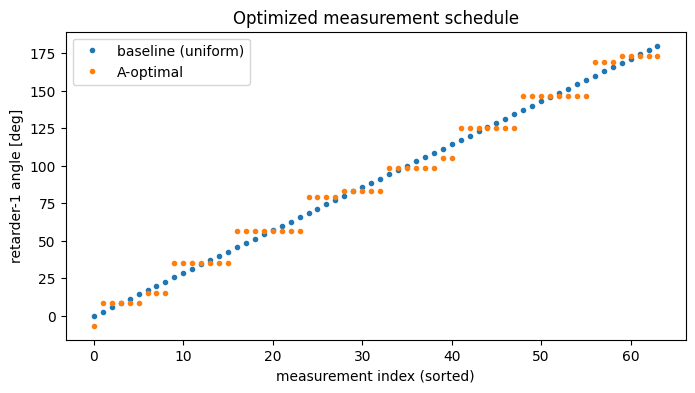

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(np.degrees(np.sort(baseline)), ".", label="baseline (uniform)")
plt.plot(np.degrees(np.sort(sched_A)), ".", label="A-optimal")
plt.xlabel("measurement index (sorted)")
plt.ylabel("retarder-1 angle [deg]")
plt.title("Optimized measurement schedule")
plt.legend()
plt.show()

## Minimum joint covariance (D-optimality)

For completeness we also optimize the D-optimality criterion, which shrinks the *joint* confidence ellipsoid rather than the sum of marginals. The volume of that ellipsoid scales as $(\det\mathbf{F})^{-1/2}$, so the improvement factor is $\exp\!\big[-\tfrac12(\log\det\mathbf{F}_{\text{opt}}-\log\det\mathbf{F}_{\text{base}})\big]$.

In [9]:
sched = baseline
optimizer = optax.adam(1e-2)
opt_state = optimizer.init(sched)
vg_D = jax.jit(jax.value_and_grad(neg_logdet_fisher))

for step in range(800):
    loss, grads = vg_D(sched)
    updates, opt_state = optimizer.update(grads, opt_state)
    sched = optax.apply_updates(sched, updates)

sched_D = sched

logdet_base = float(-neg_logdet_fisher(baseline))
logdet_D = float(-neg_logdet_fisher(sched_D))
vol_ratio = float(np.exp(-0.5 * (logdet_D - logdet_base)))
print(f"log det F : baseline {logdet_base:.3f}  ->  D-optimal {logdet_D:.3f}")
print(f"joint confidence-ellipsoid volume shrinks by ~{1/vol_ratio:.1f}x")

log det F : baseline 53.387  ->  D-optimal 55.980
joint confidence-ellipsoid volume shrinks by ~3.7x


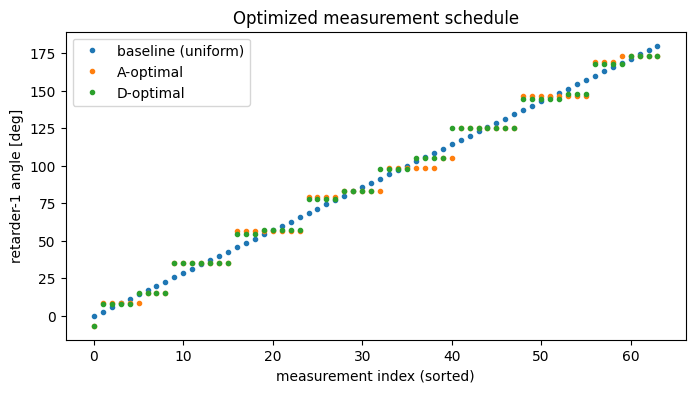

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(np.degrees(np.sort(baseline)), ".", label="baseline (uniform)")
plt.plot(np.degrees(np.sort(sched_A)), ".", label="A-optimal")
plt.plot(np.degrees(np.sort(sched_D)), ".", label="D-optimal")
plt.xlabel("measurement index (sorted)")
plt.ylabel("retarder-1 angle [deg]")
plt.title("Optimized measurement schedule")
plt.legend()
plt.show()

## Confirming the payoff with the full posterior

The Fisher matrix is only the Gaussian (Laplace) approximation to the covariance. To confirm that the A-optimal schedule really does tighten the posterior, we run the *same* Bayesian calibration as the companion notebook under both schedules and compare the sampled marginals.

For each schedule we simulate a noisy air measurement from the nominal instrument (using the **same** PRNG key so the comparison is apples-to-apples), then sample the posterior with `blackjax` NUTS.

In [11]:
def simulate_and_sample(sched, key, num_warmup=400, num_samples=2000):
    # Simulate a noisy air measurement from the nominal instrument.
    truth_power = predict(nominal, sched)
    key, noise_key = jax.random.split(key)
    data = truth_power + sigma * jax.random.normal(noise_key, truth_power.shape)

    def log_posterior(p):
        pvec = np.array([p[k] for k in order])
        observed = predict(pvec, sched)
        log_like = -0.5 * np.sum(((observed - data) / sigma) ** 2)
        log_prior = sum(-0.5 * ((p[k] - prior_mu[k]) / prior_sigma) ** 2 for k in p)
        return log_like + log_prior

    init = {k: np.array(v) for k, v in prior_mu.items()}
    key, warmup_key = jax.random.split(key)
    warmup = blackjax.window_adaptation(
        blackjax.nuts, log_posterior, target_acceptance_rate=0.8
    )
    (last_state, tuned), _ = warmup.run(warmup_key, init, num_steps=num_warmup)
    nuts = blackjax.nuts(log_posterior, **tuned)

    def one_step(state, k):
        state, _ = nuts.step(k, state)
        return state, state.position

    key, sample_key = jax.random.split(key)
    keys = jax.random.split(sample_key, num_samples)
    _, positions = jax.lax.scan(one_step, last_state, keys)
    return positions


# Same PRNG key for both, so differences come from the schedule, not the noise.
samples_base = simulate_and_sample(baseline, jax.random.PRNGKey(0))
samples_A = simulate_and_sample(sched_A, jax.random.PRNGKey(0))
samples_D = simulate_and_sample(sched_D, jax.random.PRNGKey(0))

print(f"\n{'parameter':28s} {'baseline':>10s} {'A-optimal':>10s}")
for k in order:
    s0 = float(np.degrees(np.std(samples_base[k])))
    sA = float(np.degrees(np.std(samples_A[k])))
    sD = float(np.degrees(np.std(samples_A[k])))
    print(f"  {k:26s} {s0:9.3f} {sA:10.3f}   (NUTS 1-sigma [deg])")


parameter                      baseline  A-optimal
  pol_gen.transmission_axis      5.874      6.021   (NUTS 1-sigma [deg])
  ret1.retardance                0.752      0.491   (NUTS 1-sigma [deg])
  ret1.start_angle               5.872      6.016   (NUTS 1-sigma [deg])
  ret2.retardance                0.747      0.512   (NUTS 1-sigma [deg])
  ret2.start_angle               5.889      6.025   (NUTS 1-sigma [deg])
  pol_ana.transmission_axis      5.884      6.019   (NUTS 1-sigma [deg])


## The corner plot: baseline vs optimized posterior

Overlaying the two NUTS posteriors makes the effect visual. Look at the $\delta_1$ and $\delta_2$ panels: the optimized posterior (orange) is markedly narrower than the baseline (blue), confirming the Fisher prediction. The polarizer-axis and start-angle panels barely move — those directions are prior-limited, so no schedule tightens them (at the percent level they may even drift slightly, since A-optimality spends its budget where there is leverage, i.e. on the retardances). Dashed lines mark the true parameters.

Parameter $p_1$ [rad] in chain A-optimal schedule is not constrained
Parameter $\theta_1$ [rad] in chain A-optimal schedule is not constrained
Parameter $\theta_2$ [rad] in chain D-optimal schedule is not constrained
Parameter $p_2$ [rad] in chain D-optimal schedule is not constrained


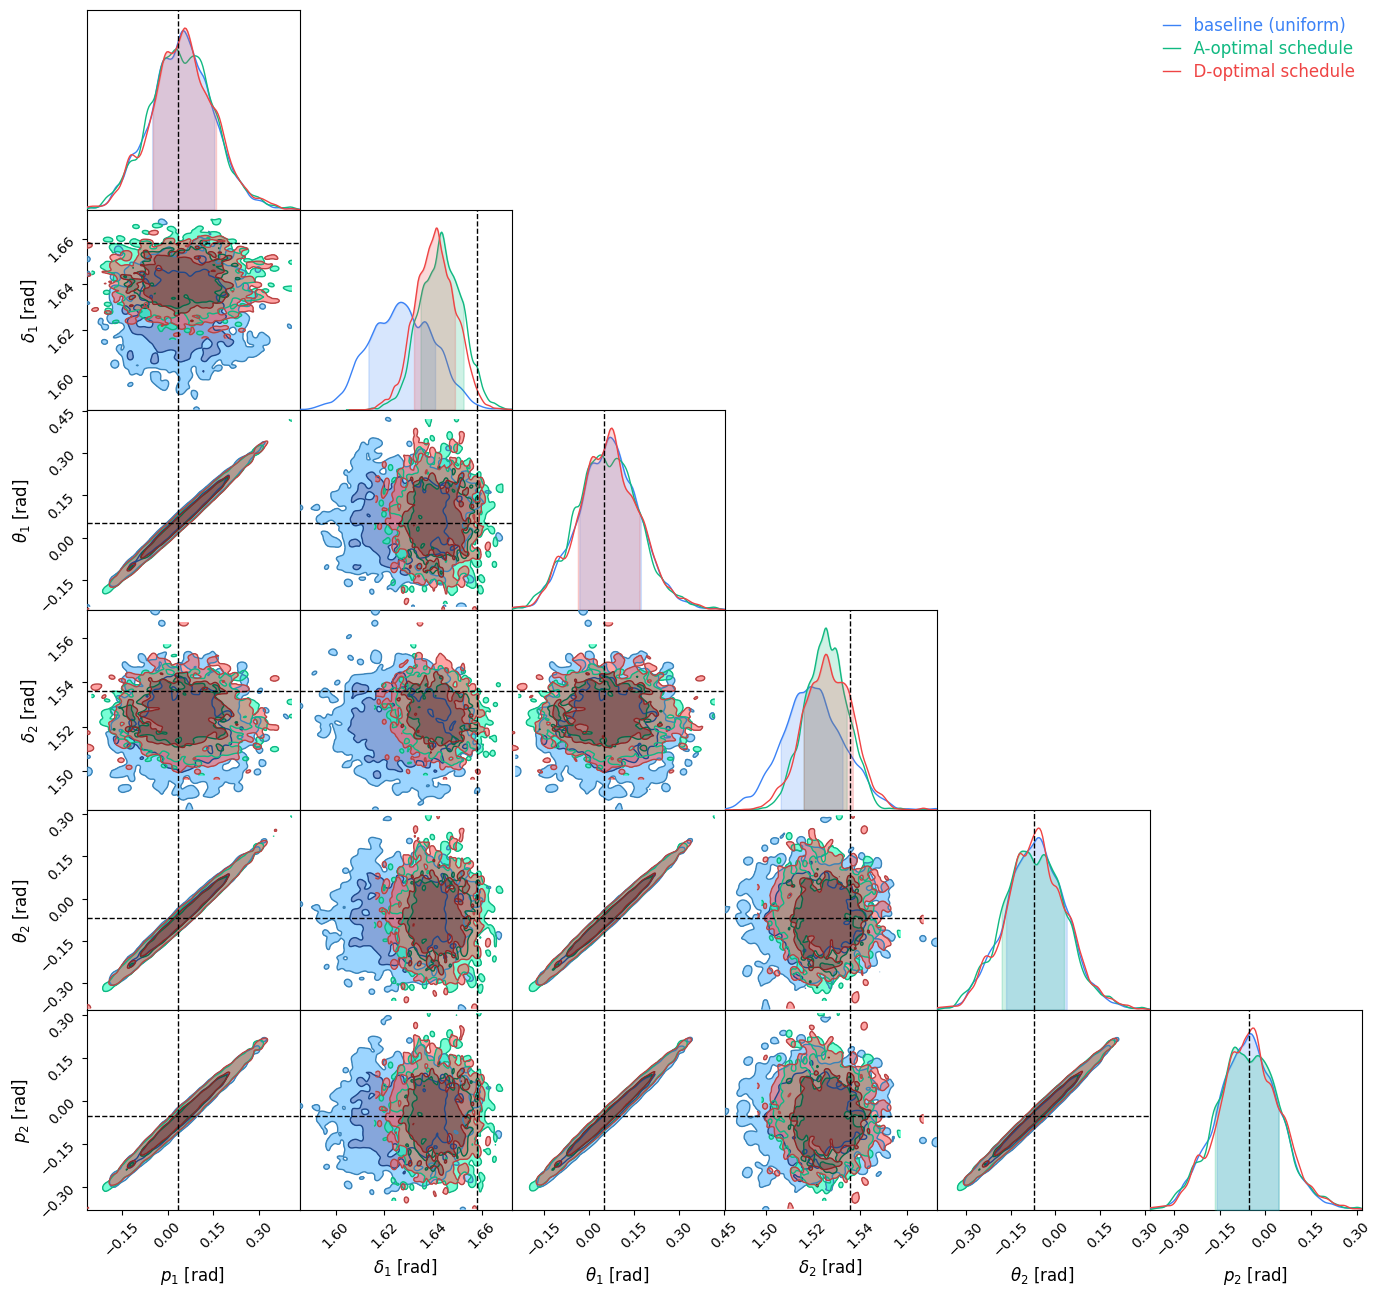

In [12]:
from chainconsumer import ChainConsumer, Chain, Truth

labels = {
    "pol_gen.transmission_axis": r"$p_1$ [rad]",
    "ret1.retardance": r"$\delta_1$ [rad]",
    "ret1.start_angle": r"$\theta_1$ [rad]",
    "ret2.retardance": r"$\delta_2$ [rad]",
    "ret2.start_angle": r"$\theta_2$ [rad]",
    "pol_ana.transmission_axis": r"$p_2$ [rad]",
}

df_base = pd.DataFrame({labels[k]: jax.device_get(samples_base[k]) for k in order})
df_A = pd.DataFrame({labels[k]: jax.device_get(samples_A[k]) for k in order})
df_D = pd.DataFrame({labels[k]: jax.device_get(samples_D[k]) for k in order})

cc = ChainConsumer()
cc.add_chain(Chain(samples=df_base, name="baseline (uniform)"))
cc.add_chain(Chain(samples=df_A, name="A-optimal schedule"))
cc.add_chain(Chain(samples=df_D, name="D-optimal schedule"))
cc.add_truth(Truth(location={labels[k]: float(nominal[i]) for i, k in enumerate(order)}))
cc.plotter.plot()
plt.show()

## Takeaways

- The **rotation schedule is a design variable**, and because `katsu` models are differentiable the whole parameter covariance $\mathbf{C}=\mathbf{F}^{-1}$ is a differentiable function of it. Optimizing the schedule is the *same* `optax` loop as calibration, with the rotation angles promoted to free variables.
- **A-optimality** (minimize $\operatorname{tr}\mathbf{C}$) targets the marginal bounds; **D-optimality** (maximize $\log\det\mathbf{F}$) targets the joint confidence volume. They answer subtly different questions — pick the one that matches what you care about.
- Optimizing the schedule **tightens the retardance marginals by roughly a third**, confirmed independently by NUTS. The polarizer-axis and start-angle directions are near-degenerate and prior-limited, so no schedule improves them — a limit that better priors, extra hardware, or breaking the $1\!:\!5$ gear degeneracy would address, but scheduling alone cannot.
- Because $\mathbf{F}$ depends on the unknown truth, this is **locally optimal design**: optimize at your best nominal instrument, calibrate, and iterate.